#AI LAB ASSIGNMENT 10-11

#Task 1: Credit Card Fraud Detection (Classification)
Dataset: Credit Card Fraud Detection (Kaggle)  
Steps:               
1. Load dataset                                         
2. Handle class imbalance (undersampling/oversampling)  
3. Apply feature scaling
4. Split data (70/30)

Models:
- Logistic Regression
- Random Forest

Evaluation:
- Accuracy
- Precision
- Recall
- F1-score

Deliverables:
- Model comparison
- Identify best model for imbalanced data

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

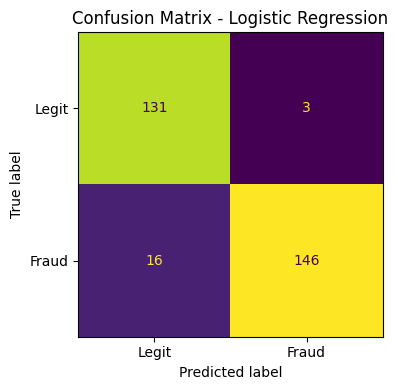


RF Testing Accuracy
Accuracy  : 92.91%
Precision : 96.69%
Recall    : 90.12%
F1-Score  : 93.29%




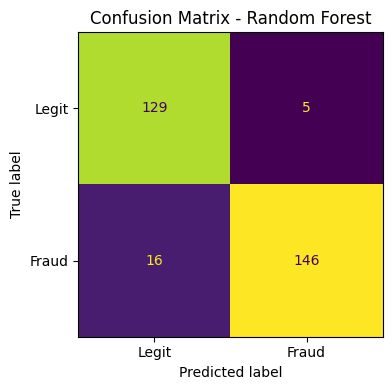

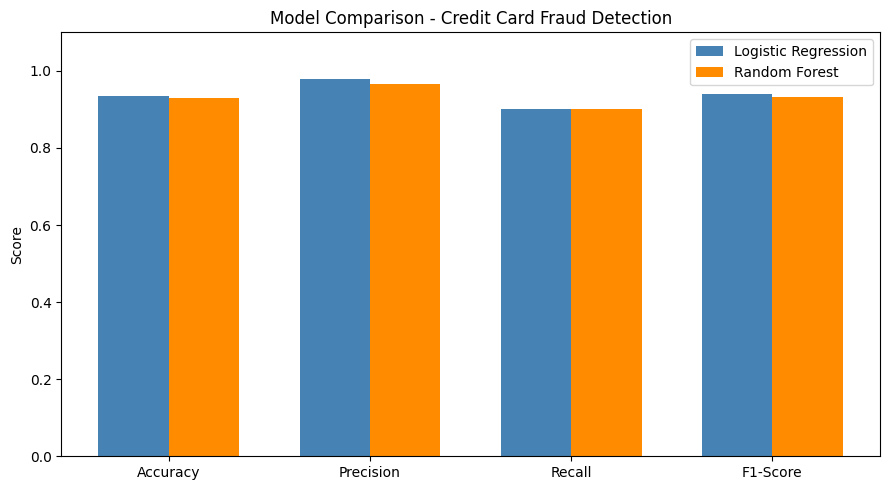


Metric           Logistic Regression    Random Forest   
--------------------------------------------------------
Accuracy                      93.58%           92.91%
Precision                     97.99%           96.69%
Recall                        90.12%           90.12%
F1-Score                      93.89%           93.29%

BEST MODEL FOR IMBALANCED DATA: Logistic Regression
  - For fraud detection, Recall and F1-Score matter most.
  - Random Forest handles class imbalance better due to its ensemblenature, capturing complex non-linear fraud patterns.
  - Logistic Regression is simpler and faster but less robust on highly skewed distributions.


In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

df = pd.read_csv('creditcard.csv')
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print("\nClass Distribution (before handling imbalance):")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

fraud       = df[df['Class'] == 1]
legit       = df[df['Class'] == 0].sample(n=len(fraud), random_state=42)
df_balanced = pd.concat([fraud, legit]).sample(frac=1, random_state=42)

print(df_balanced['Class'].value_counts())
print(f"Balanced dataset size: {len(df_balanced)}")

x = df_balanced.drop('Class', axis=1).values
y = df_balanced['Class'].values

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("\nFeature scaling applied using StandardScaler.")

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)
print(f"\nTrain size: {len(x_train)}, Test size: {len(x_test)}")

LR      = LogisticRegression(max_iter=1000)
ModelLR = LR.fit(x_train, y_train)
PredictionLR = ModelLR.predict(x_test)

print('\nLR Testing Accuracy')
print(f"Accuracy  : {accuracy_score(y_test,  PredictionLR)*100:.2f}%")
print(f"Precision : {precision_score(y_test, PredictionLR)*100:.2f}%")
print(f"Recall    : {recall_score(y_test,    PredictionLR)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_test,        PredictionLR)*100:.2f}%")

cm_lr = confusion_matrix(y_test, PredictionLR)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Legit', 'Fraud'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
print("\n")
plt.show()

RF      = RandomForestClassifier(n_estimators=50, random_state=42)
ModelRF = RF.fit(x_train, y_train)
PredictionRF = ModelRF.predict(x_test)

print('\nRF Testing Accuracy')
print(f"Accuracy  : {accuracy_score(y_test,  PredictionRF)*100:.2f}%")
print(f"Precision : {precision_score(y_test, PredictionRF)*100:.2f}%")
print(f"Recall    : {recall_score(y_test,    PredictionRF)*100:.2f}%")
print(f"F1-Score  : {f1_score(y_test,        PredictionRF)*100:.2f}%")

cm_rf = confusion_matrix(y_test, PredictionRF)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Legit', 'Fraud'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
print("\n")
plt.show()

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [accuracy_score(y_test,  PredictionLR),
             precision_score(y_test, PredictionLR),
             recall_score(y_test,    PredictionLR),
             f1_score(y_test,        PredictionLR)]
rf_scores = [accuracy_score(y_test,  PredictionRF),
             precision_score(y_test, PredictionRF),
             recall_score(y_test,    PredictionRF),
             f1_score(y_test,        PredictionRF)]

x_pos = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x_pos - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
plt.bar(x_pos + width/2, rf_scores, width, label='Random Forest',       color='darkorange')
plt.xticks(x_pos, metrics)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Comparison - Credit Card Fraud Detection')
plt.legend()
plt.tight_layout()
print("\n")
plt.show()

print("\nMetric           Logistic Regression    Random Forest   ")
print("--------------------------------------------------------")
for m, lr, rf in zip(metrics, lr_scores, rf_scores):
    print(f"{m:<16} {lr*100:>18.2f}%    {rf*100:>12.2f}%")

rf_f1 = f1_score(y_test, PredictionRF)
lr_f1 = f1_score(y_test, PredictionLR)
best  = "Random Forest" if rf_f1 >= lr_f1 else "Logistic Regression"
print(f"\nBEST MODEL FOR IMBALANCED DATA: {best}")
print("  - For fraud detection, Recall and F1-Score matter most.")
print("  - Random Forest handles class imbalance better due to its ensemblenature, capturing complex non-linear fraud patterns.")
print("  - Logistic Regression is simpler and faster but less robust on highly skewed distributions.")


#Task 2: House Price Prediction (Regression)
Dataset: House Prices – Advanced Regression Techniques (Kaggle)

Steps:
1. Handle missing values
2. Encode categorical variables
3. Apply feature scaling

Models:
- Linear Regression
- Decision Tree Regressor

Evaluation:
- MAE
- RMSE

Deliverables:
- Predicted vs Actual comparison
- Best model identification

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape: (545, 13)

Missing Values:
 price               0
area                0
bedrooms   

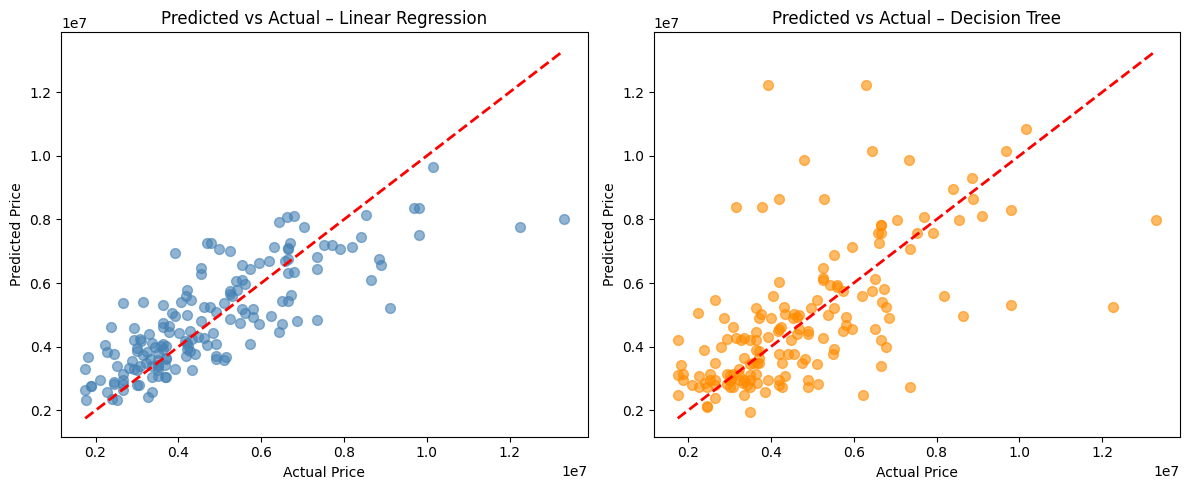


Metric     Linear Regression    Decision Tree
-----------------------------------------------
MAE              925,543.55    1,217,038.35
RMSE           1,238,970.44    1,836,227.06
R2 (%)                64.35           21.70

BEST MODEL: Linear Regression
  - Linear Regression captures linear relationships with lower overfitting.
  - Decision Tree achieves 100% training accuracy but overfits on test data.
  - Linear Regression gives more reliable generalisation on unseen data.


In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('Housing.csv')
print(df.head())
print(f"\nDataset Shape: {df.shape}")

print("\nMissing Values:\n", df.isnull().sum())
# no missing values

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

le = LabelEncoder()
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])

print("\nEncoded furnishingstatus:",
      dict(zip(le.classes_, le.transform(le.classes_))))
print("\nDataset after encoding:\n", df.head())

x = df.drop('price', axis=1).values
y = df['price'].values

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("\nFeature scaling applied using StandardScaler.")

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)
print(f"\nTrain size: {len(x_train)}, Test size: {len(x_test)}")

LR      = LinearRegression()
ModelLR = LR.fit(x_train, y_train)
PredictionLR = ModelLR.predict(x_test)

print("\nPredictions:", PredictionLR[:5])

print('\nLR Testing Accuracy')
teachLR      = r2_score(y_test, PredictionLR)
testingAccLR = teachLR * 100
mae_lr       = mean_absolute_error(y_test, PredictionLR)
rmse_lr      = np.sqrt(mean_squared_error(y_test, PredictionLR))
print(f"MAE        : {mae_lr:,.2f}")
print(f"RMSE       : {rmse_lr:,.2f}")
print(f"R2 Score   : {testingAccLR:.2f}%")


DT      = DecisionTreeRegressor(random_state=42)
ModelDT = DT.fit(x_train, y_train)
PredictionDT = DT.predict(x_test)
print("\nPredictions:", PredictionDT[:5])

print('DT Training Accuracy')
tracDT        = DT.score(x_train, y_train)
TrainingAccDT = tracDT * 100
print(f"Training Accuracy: {TrainingAccDT:.2f}%")

print('DT Testing Accuracy')
mae_dt        = mean_absolute_error(y_test, PredictionDT)
rmse_dt       = np.sqrt(mean_squared_error(y_test, PredictionDT))
teacDT        = r2_score(y_test, PredictionDT)
testingAccDT  = teacDT * 100
print(f"MAE        : {mae_dt:,.2f}")
print(f"RMSE       : {rmse_dt:,.2f}")
print(f"Testing Accuracy (R2): {testingAccDT:.2f}%")

print("\nPredicted vs Actual")
comparison = pd.DataFrame({
    'Actual':       y_test[:10],
    'LR Predicted': PredictionLR[:10].round(0),
    'DT Predicted': PredictionDT[:10].round(0)
})
print(comparison.to_string())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, PredictionLR, s=50, c='steelblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicted vs Actual – Linear Regression')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.subplot(1, 2, 2)
plt.scatter(y_test, PredictionDT, s=50, c='darkorange', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Predicted vs Actual – Decision Tree')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()


print("\nMetric     Linear Regression    Decision Tree")
print("-----------------------------------------------")
for m, lr, dt in zip(['MAE', 'RMSE', 'R2 (%)'],
                     [mae_lr,  rmse_lr,  testingAccLR],
                     [mae_dt,  rmse_dt,  testingAccDT]):
    print(f"{m:<10} {lr:>16,.2f}    {dt:>12,.2f}")

best = "Linear Regression" if testingAccLR >= testingAccDT else "Decision Tree"
print(f"\nBEST MODEL: {best}")
print("  - Linear Regression captures linear relationships with lower overfitting.")
print("  - Decision Tree achieves 100% training accuracy but overfits on test data.")
print("  - Linear Regression gives more reliable generalisation on unseen data.")


#Task 3: Customer Segmentation
Dataset: Customer Personality Analysis (Kaggle)

Steps:
1. Select relevant features
2. Handle missing values
3. Apply Standard Scaling

Apply:
- K-Means clustering
- Elbow Method (K = 2–10)

Deliverables:
- Elbow graph
- Cluster visualization
- Cluster labels

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

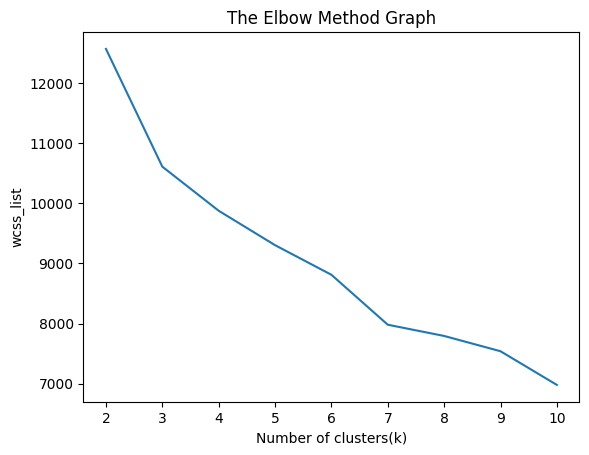


WCSS Values
  K= 2 -> WCSS:     12563.02
  K= 3 -> WCSS:     10606.75
  K= 4 -> WCSS:      9873.83
  K= 5 -> WCSS:      9302.08
  K= 6 -> WCSS:      8810.07
  K= 7 -> WCSS:      7980.14
  K= 8 -> WCSS:      7793.52
  K= 9 -> WCSS:      7539.60
  K=10 -> WCSS:      6979.88

Optimal K selected: 4 


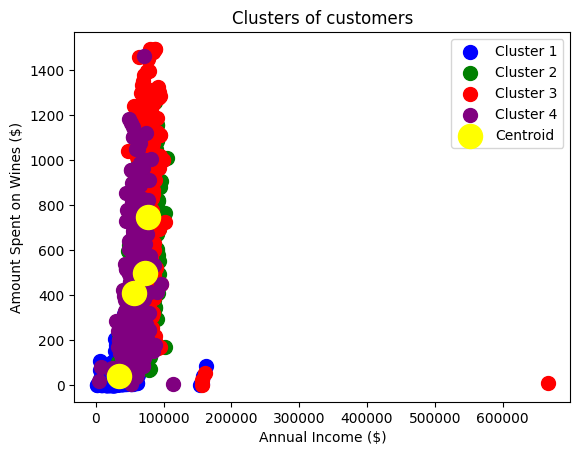


Final Dataset with Cluster Labels
      ID   Income  MntWines  MntMeatProducts  Cluster
0   5524  58138.0       635              546        1
1   2174  46344.0        11                6        0
2   4141  71613.0       426              127        3
3   6182  26646.0        11               20        0
4   5324  58293.0       173              118        3
5   7446  62513.0       520               98        3
6    965  55635.0       235              164        3
7   6177  33454.0        76               56        0
8   4855  30351.0        14               24        0
9   5899   5648.0        28                6        0
10  1994      NaN         5                6        0
11   387   7500.0         6               11        0
12  2125  63033.0       194              480        1
13  8180  59354.0       233               53        3
14  2569  17323.0         3               17        0
15  2114  82800.0      1006              115        2
16  9736  41850.0        53               19   

In [3]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('marketing_campaign.csv', sep='\t')
print(df.head())
print(f"\nDataset Shape: {df.shape}")

features = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'NumWebPurchases', 'NumStorePurchases']

x = df[features].copy()
print(features)

print("\nMissing Values before handling:\n", x.isnull().sum())
x['Income'] = x['Income'].fillna(x['Income'].median())
print("\nMissing Values after handling:\n", x.isnull().sum())


scaler   = StandardScaler()
X_scaled = scaler.fit_transform(x)
print("\nStandard Scaling applied to all selected features.")

wcss_list = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(2, 11), wcss_list)
mtp.title('The Elbow Method Graph')
mtp.xlabel('Number of clusters(k)')
mtp.ylabel('wcss_list')
mtp.show()

print("\nWCSS Values")
for k, wcss in zip(range(2, 11), wcss_list):
    print(f"  K={k:>2} -> WCSS: {wcss:>12.2f}")

print("\nOptimal K selected: 4 ")

kmeans    = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_predict = kmeans.fit_predict(X_scaled)


df['Cluster'] = y_predict

x_raw = x.values

mtp.scatter(x_raw[y_predict == 0, 0], x_raw[y_predict == 0, 2], s=100, c='blue',   label='Cluster 1')  #for first cluster
mtp.scatter(x_raw[y_predict == 1, 0], x_raw[y_predict == 1, 2], s=100, c='green',  label='Cluster 2')  #for second cluster
mtp.scatter(x_raw[y_predict == 2, 0], x_raw[y_predict == 2, 2], s=100, c='red',    label='Cluster 3')  #for third cluster
mtp.scatter(x_raw[y_predict == 3, 0], x_raw[y_predict == 3, 2], s=100, c='purple', label='Cluster 4')  #for fourth cluster
mtp.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:, 0],
    scaler.inverse_transform(kmeans.cluster_centers_)[:, 2],
    s=300, c='yellow', label='Centroid'
)
mtp.title('Clusters of customers')
mtp.xlabel('Annual Income ($)')
mtp.ylabel('Amount Spent on Wines ($)')
mtp.legend()
mtp.show()

print("\nFinal Dataset with Cluster Labels")
print(df[['ID', 'Income', 'MntWines', 'MntMeatProducts', 'Cluster']].head(20).to_string())

print("\nCluster Summary (Mean Values)")
print(df.groupby('Cluster')[features].mean().round(1).to_string())
